MSE: 1.8269453307184897
MAE: 1.1376870145663869
RMSE: 1.3516454160461204
R2 Score: 0.9878178107462451
Train R2: 0.9878083101883538
Test R2: 0.9878178107462451
CV R2 scores: [0.94391259 0.95708943 0.98937659 0.99174667 0.99173856]
Mean CV R2: 0.9747727679635311
Std CV R2: 0.02026955420737245


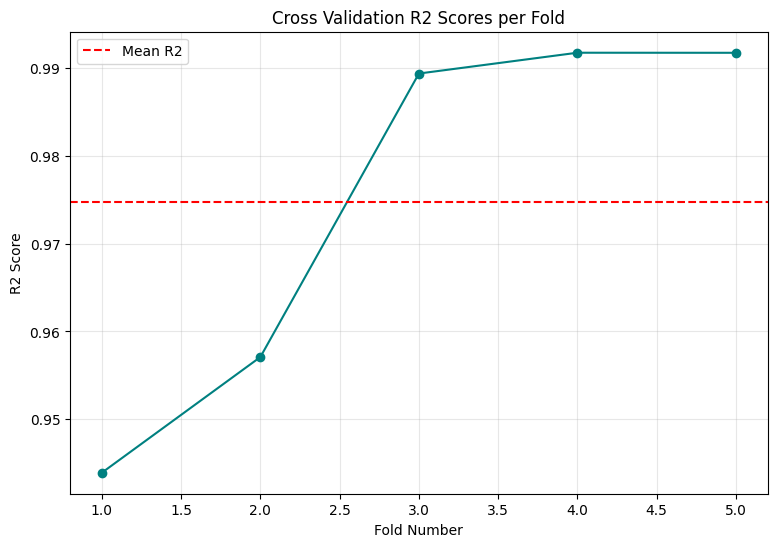

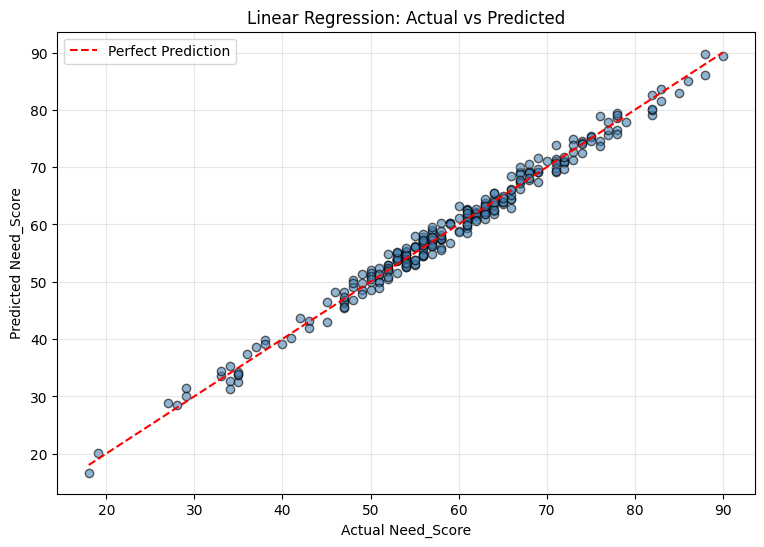

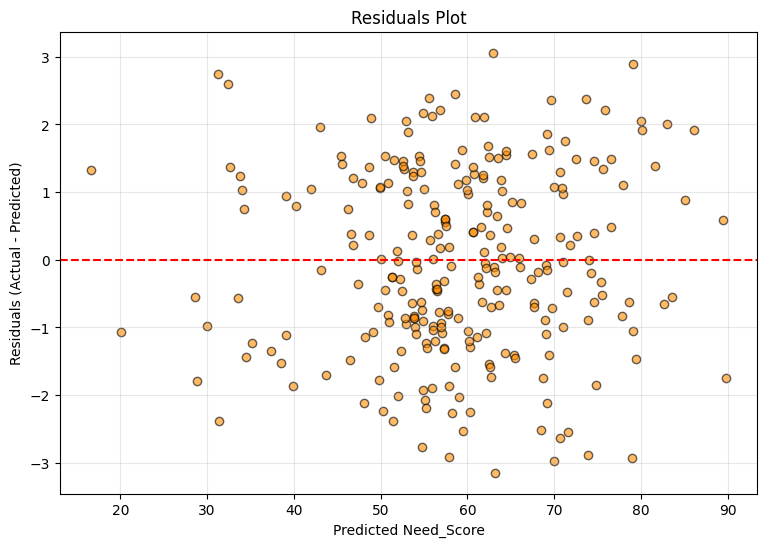

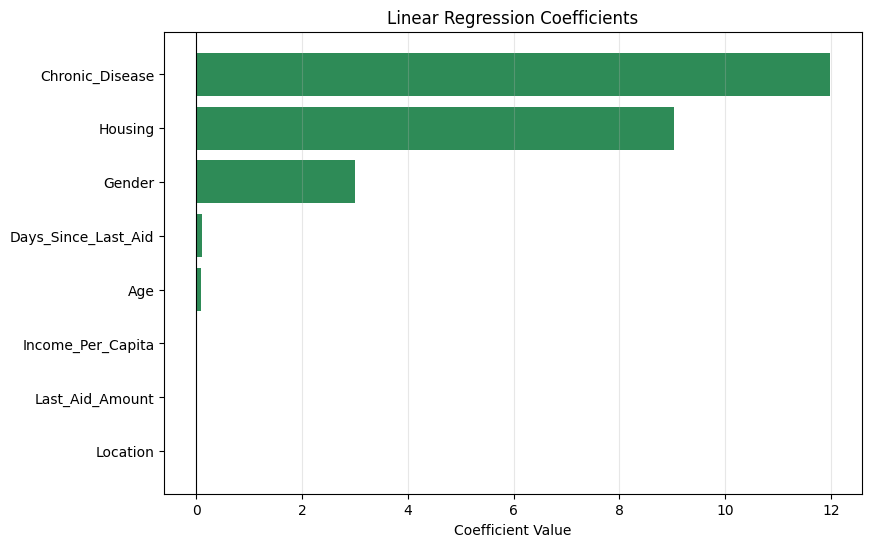

{'Model': 'Linear Regression', 'MSE': 1.8269453307184897, 'MAE': 1.1376870145663869, 'RMSE': np.float64(1.3516454160461204), 'R2 Score': 0.9878178107462451, 'Mean CV R2': np.float64(0.9747727679635311)}


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import category_encoders as ce

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv("يارب_تكون_اخر_مرة.csv")

df.head()

# ============================================================
# Check for missing values
# ============================================================
df.isnull().sum()

# ============================================================
# Drop columns that shouldn't be used by the model
# ============================================================
df_model = df.drop(['ID', 'Name', 'Category', 'Monthly_Income','Dependents'], axis=1)

df_model.head()

# ============================================================
# Encode categorical columns
# ============================================================
encoder = ce.OrdinalEncoder(cols=['Gender', 'Location'])
df_encoded = encoder.fit_transform(df_model)

df_encoded.head()

# ============================================================
# Prepare data
# ============================================================
x = df_encoded.drop(['Need_Score'], axis=1)
y = df_encoded['Need_Score']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

x_train.shape, x_test.shape

# ============================================================
# Train Linear Regression
# ============================================================
lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

# ============================================================
# Accuracy with 3 error types + R2
# ============================================================
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ============================================================
# Check overfitting (train vs test)
# ============================================================
train_pred = lr.predict(x_train)
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred))

# ============================================================
# Cross Validation
# ============================================================
cv_scores = cross_val_score(lr, x, y, cv=5, scoring='r2')

print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

# ============================================================
# Plot: Cross Validation scores across folds
# ============================================================
plt.figure(figsize=(9, 6))
plt.plot(range(1, 6), cv_scores, marker="o", color='teal')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label='Mean R2')
plt.xlabel("Fold Number")
plt.ylabel("R2 Score")
plt.title("Cross Validation R2 Scores per Fold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot: Actual vs Predicted
# ============================================================
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Need_Score")
plt.ylabel("Predicted Need_Score")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# ============================================================
# Plot: Residuals
# ============================================================
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='darkorange', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Need_Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Plot")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot: Feature coefficients
# ============================================================
coef_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(coef_df["Feature"][::-1], coef_df["Coefficient"][::-1], color='seagreen')
plt.xlabel("Coefficient Value")
plt.title("Linear Regression Coefficients")
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(alpha=0.3, axis='x')
plt.show()

# ============================================================
# Save this model's accuracy for later comparison
# ============================================================
linear_regression_results = {
    "Model": "Linear Regression",
    "MSE": mse,
    "MAE": mae,
    "RMSE": rmse,
    "R2 Score": r2,
    "Mean CV R2": cv_scores.mean()
}

print(linear_regression_results)


MSE: 20.68490421455939
MAE: 3.4199233716475095
RMSE: 4.548065986170318
R2 Score: 0.862071725080873
Train R2: 0.893622923254481
Test R2: 0.862071725080873
CV R2 scores: [0.6787358  0.82538858 0.8170025  0.84840321 0.80831434]
Mean CV R2: 0.7955688860415242
Std CV R2: 0.059920775430485324


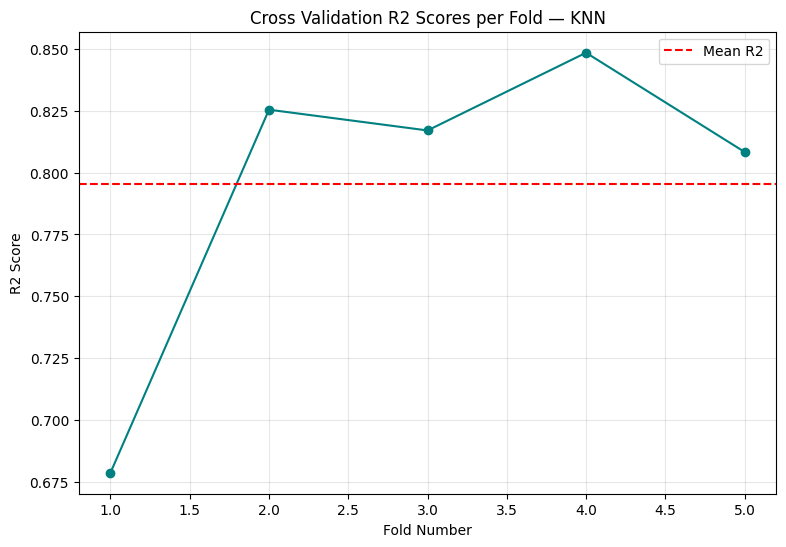

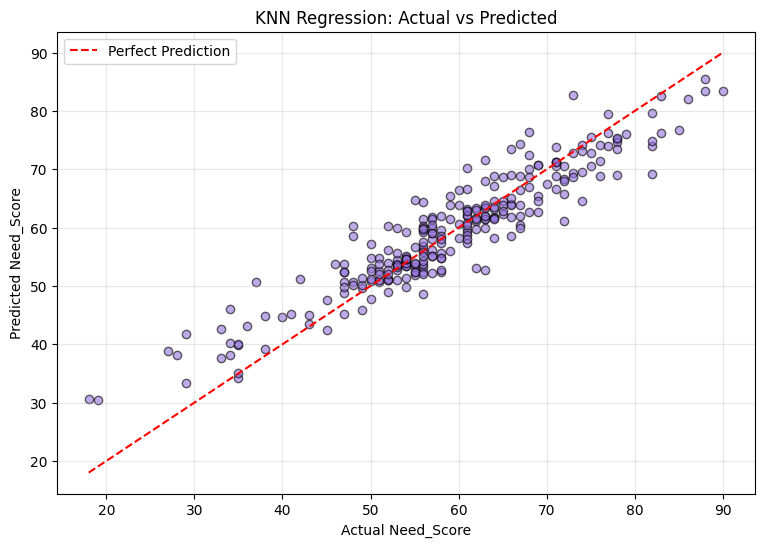

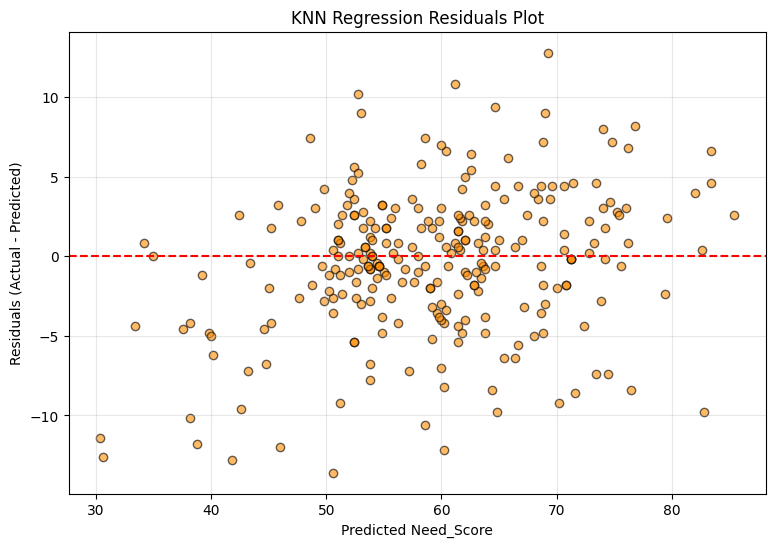

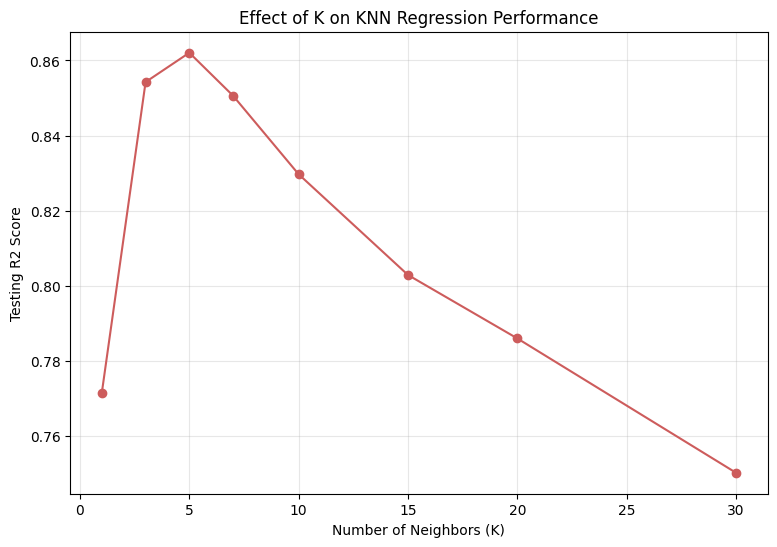

{'Model': 'KNN', 'MSE': 20.68490421455939, 'MAE': 3.4199233716475095, 'RMSE': np.float64(4.548065986170318), 'R2 Score': 0.862071725080873, 'Mean CV R2': np.float64(0.7955688860415242)}


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import category_encoders as ce

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv("يارب_تكون_اخر_مرة.csv")

df.head()

# ============================================================
# Check for missing values
# ============================================================
df.isnull().sum()

# ============================================================
# Drop columns that shouldn't be used by the model
# ============================================================
df_model = df.drop(['ID', 'Name', 'Category', 'Monthly_Income'], axis=1)

df_model.head()

# ============================================================
# Encode categorical columns
# ============================================================
encoder = ce.OrdinalEncoder(cols=['Gender', 'Location'])
df_encoded = encoder.fit_transform(df_model)

df_encoded.head()

# ============================================================
# Prepare data
# ============================================================
x = df_encoded.drop(['Need_Score'], axis=1)
y = df_encoded['Need_Score']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

x_train.shape, x_test.shape

# ============================================================
# Scale features (KNN needs scaling since it's distance-based)
# ============================================================
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_scaled = scaler.transform(x)

# ============================================================
# Train KNN Regressor
# ============================================================
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train_scaled, y_train)

y_pred = knn.predict(x_test_scaled)

# ============================================================
# Accuracy with 3 error types + R2
# ============================================================
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ============================================================
# Check overfitting (train vs test)
# ============================================================
train_pred = knn.predict(x_train_scaled)
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred))

# ============================================================
# Cross Validation
# ============================================================
cv_scores = cross_val_score(knn, x_scaled, y, cv=5, scoring='r2')

print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

# ============================================================
# Plot: Cross Validation scores across folds
# ============================================================
plt.figure(figsize=(9, 6))
plt.plot(range(1, 6), cv_scores, marker="o", color='teal')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label='Mean R2')
plt.xlabel("Fold Number")
plt.ylabel("R2 Score")
plt.title("Cross Validation R2 Scores per Fold — KNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# ============================================================
# Plot: Actual vs Predicted
# ============================================================
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='mediumpurple', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Need_Score")
plt.ylabel("Predicted Need_Score")
plt.title("KNN Regression: Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot: Residuals
# ============================================================
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='darkorange', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Need_Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("KNN Regression Residuals Plot")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot: Effect of K on model performance
# ============================================================
k_values = [1, 3, 5, 7, 10, 15, 20, 30]
r2_scores = []

for k in k_values:
    temp_knn = KNeighborsRegressor(n_neighbors=k)
    temp_knn.fit(x_train_scaled, y_train)
    r2_scores.append(r2_score(y_test, temp_knn.predict(x_test_scaled)))

plt.figure(figsize=(9, 6))
plt.plot(k_values, r2_scores, marker="o", color='indianred')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Testing R2 Score")
plt.title("Effect of K on KNN Regression Performance")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Save this model's accuracy for later comparison
# ============================================================
knn_results = {
    "Model": "KNN",
    "MSE": mse,
    "MAE": mae,
    "RMSE": rmse,
    "R2 Score": r2,
    "Mean CV R2": cv_scores.mean()
}

print(knn_results)

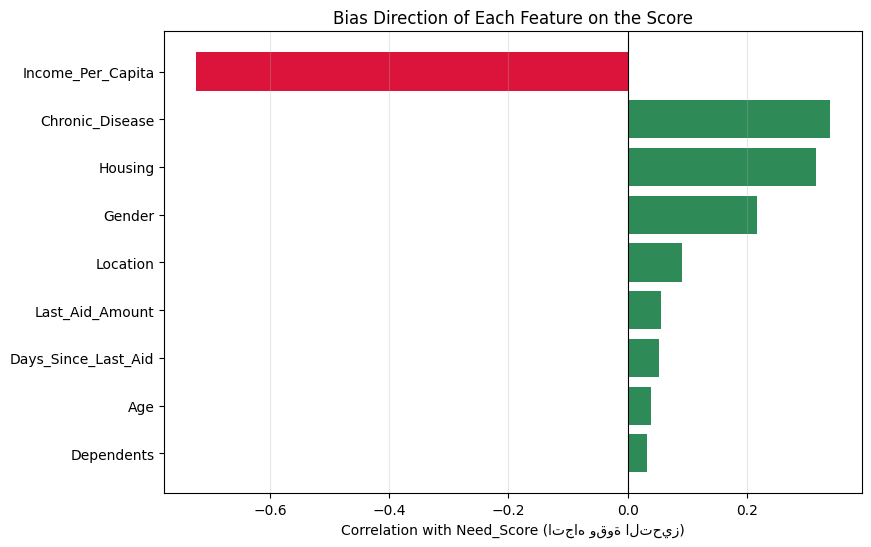

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. حساب Correlation وإنشاء bias_df لحل الـ NameError
# ============================================================
# حساب الارتباط بين كل Feature و Need_Score
correlations = x.corrwith(df['Need_Score'])

bias_df = pd.DataFrame({
    "Feature": correlations.index,
    "Correlation_with_Score": correlations.values
}).sort_values(by="Correlation_with_Score", key=abs, ascending=False)

# ============================================================
# 2. رسم يوضح قوة واتجاه التحيز لكل Feature في مكان واحد
# ============================================================
plt.figure(figsize=(9, 6))

colors = ['crimson' if v < 0 else 'seagreen' for v in bias_df['Correlation_with_Score']]

plt.barh(bias_df["Feature"][::-1], bias_df["Correlation_with_Score"][::-1], color=colors[::-1])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel("Correlation with Need_Score (اتجاه وقوة التحيز)")
plt.title("Bias Direction of Each Feature on the Score")
plt.grid(alpha=0.3, axis='x')
plt.show()


MSE: 4.366273403167725
MAE: 1.5883747339248657
RMSE: 2.0895629694191378
R2 Score: 0.9708853960037231
Train R2: 0.999585747718811
Test R2: 0.9708853960037231
CV R2 scores: [0.937029   0.95812023 0.96869558 0.9721753  0.97353071]
Mean CV R2: 0.9619101643562317
Std CV R2: 0.013563832260255768


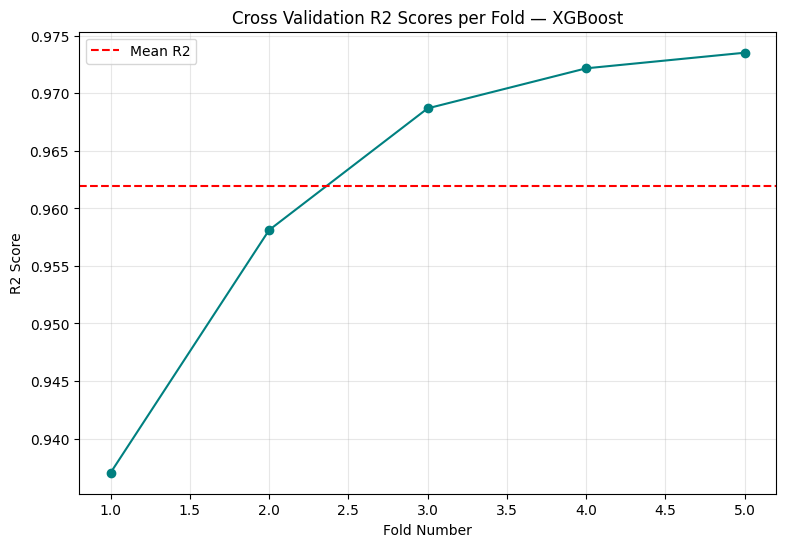

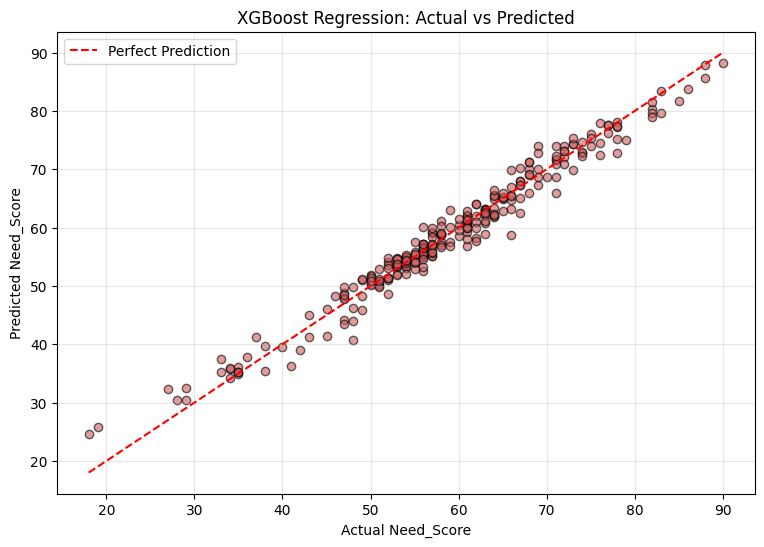

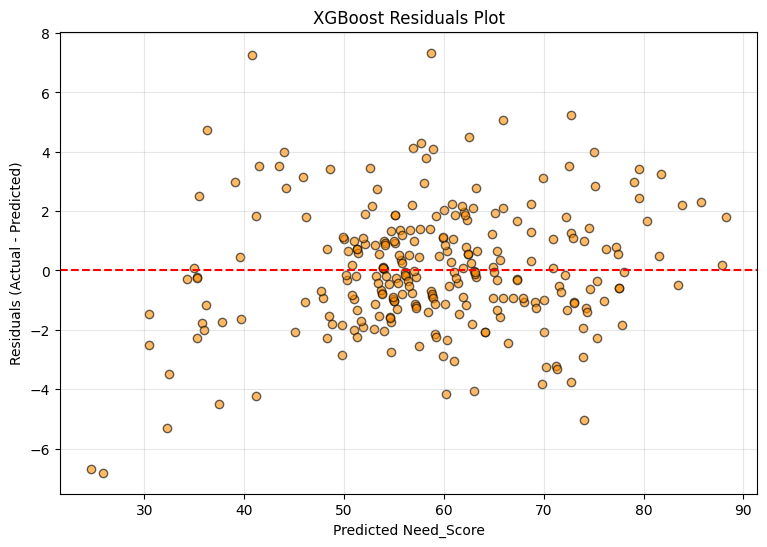


Feature Importance (XGBoost built-in):
               Feature  Importance  Percentage
5      Chronic_Disease    0.464987   46.498726
6              Housing    0.251833   25.183323
4    Income_Per_Capita    0.200461   20.046061
0               Gender    0.029182    2.918155
2             Location    0.022341    2.234087
7  Days_Since_Last_Aid    0.019890    1.988981
1                  Age    0.005962    0.596234
8      Last_Aid_Amount    0.003457    0.345668
3           Dependents    0.001888    0.188766


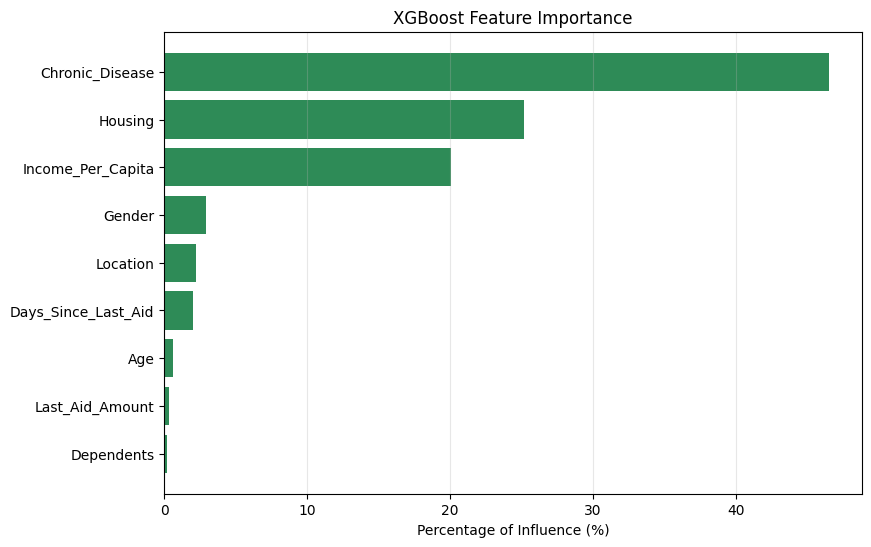

{'Model': 'XGBoost', 'MSE': 4.366273403167725, 'MAE': 1.5883747339248657, 'RMSE': np.float64(2.0895629694191378), 'R2 Score': 0.9708853960037231, 'Mean CV R2': np.float64(0.9619101643562317)}


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import category_encoders as ce

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv("يارب_تكون_اخر_مرة.csv")

df.head()

# ============================================================
# Drop columns that shouldn't be used by the model
# ============================================================
df_model = df.drop(['ID', 'Name', 'Category', 'Monthly_Income'], axis=1)

df_model.head()

# ============================================================
# Encode categorical columns
# ============================================================
encoder = ce.OrdinalEncoder(cols=['Gender', 'Location'])
df_encoded = encoder.fit_transform(df_model)

df_encoded.head()

# ============================================================
# Prepare data
# ============================================================
x = df_encoded.drop(['Need_Score'], axis=1)
y = df_encoded['Need_Score']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

x_train.shape, x_test.shape

# ============================================================
# Train XGBoost Regressor
# ============================================================
xgb = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

# ============================================================
# Accuracy with 3 error types + R2
# ============================================================
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ============================================================
# Check overfitting (train vs test)
# ============================================================
train_pred = xgb.predict(x_train)
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred))

# ============================================================
# Cross Validation
# ============================================================
cv_scores = cross_val_score(xgb, x, y, cv=5, scoring='r2')

print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

# ============================================================
# Plot: Cross Validation scores across folds
# ============================================================
plt.figure(figsize=(9, 6))
plt.plot(range(1, 6), cv_scores, marker="o", color='teal')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label='Mean R2')
plt.xlabel("Fold Number")
plt.ylabel("R2 Score")
plt.title("Cross Validation R2 Scores per Fold — XGBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot: Actual vs Predicted
# ============================================================
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='indianred', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Need_Score")
plt.ylabel("Predicted Need_Score")
plt.title("XGBoost Regression: Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot: Residuals
# ============================================================
residuals = y_test - y_pred
plt.figure(figsize=(9, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='darkorange', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Need_Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("XGBoost Residuals Plot")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Feature Importance (built-in gain-based importance)
# ============================================================
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": xgb.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance['Percentage'] = feature_importance['Importance'] / feature_importance['Importance'].sum() * 100

print("\nFeature Importance (XGBoost built-in):")
print(feature_importance)

plt.figure(figsize=(9, 6))
plt.barh(feature_importance["Feature"][::-1], feature_importance["Percentage"][::-1], color='seagreen')
plt.xlabel("Percentage of Influence (%)")
plt.title("XGBoost Feature Importance")
plt.grid(alpha=0.3, axis='x')
plt.show()

# ============================================================
# Save this model's accuracy for later comparison
# ============================================================
xgboost_results = {
    "Model": "XGBoost",
    "MSE": mse,
    "MAE": mae,
    "RMSE": rmse,
    "R2 Score": r2,
    "Mean CV R2": cv_scores.mean()
}

print(xgboost_results)


جاري تدريب النموذج وتحديد أفضل Hyperparameters...
أفضل إعدادات (Best Params): {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}

--- Test Evaluation ---
MSE: 7.362584651288996
MAE: 2.010510613907165
RMSE: 2.713408308988715
R2 Score: 0.9509058108577776

--- Overfitting Check ---
Train R2: 0.9939087227740461
Test R2: 0.9509058108577776

--- Cross Validation ---
CV R2 scores: [0.84528689 0.95263383 0.96234483 0.95737641 0.96356452]
Mean CV R2: 0.9362412941131067
Std CV R2: 0.045642227640999976


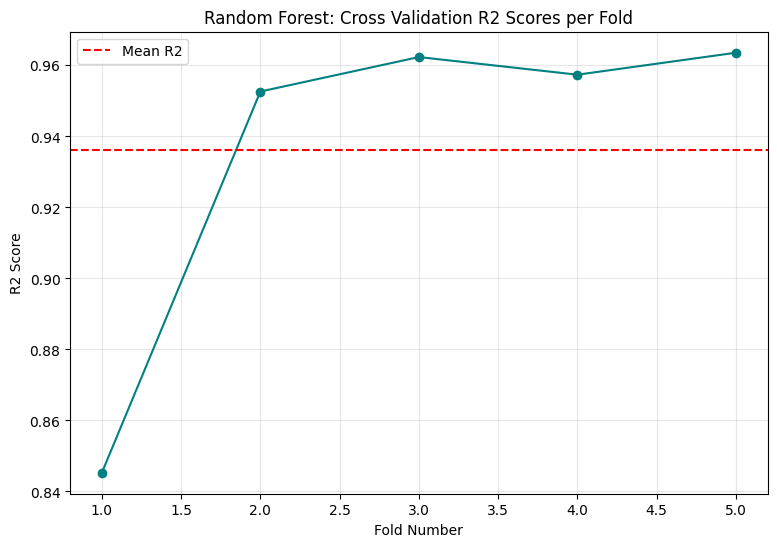

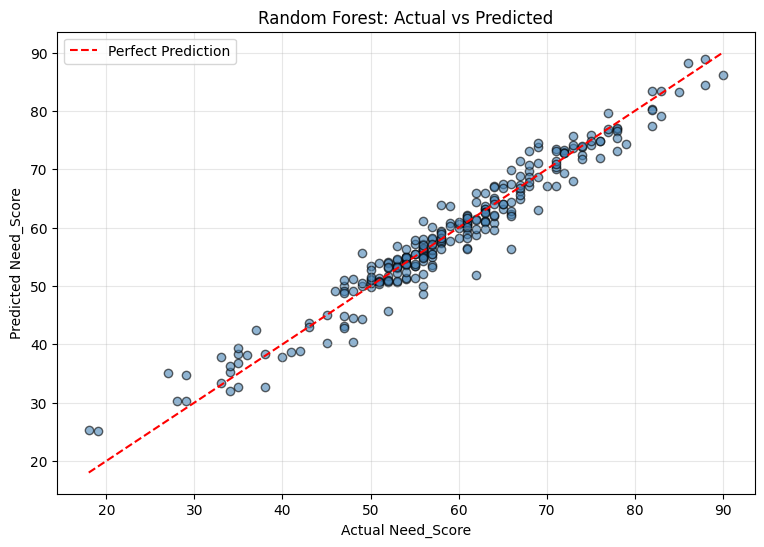

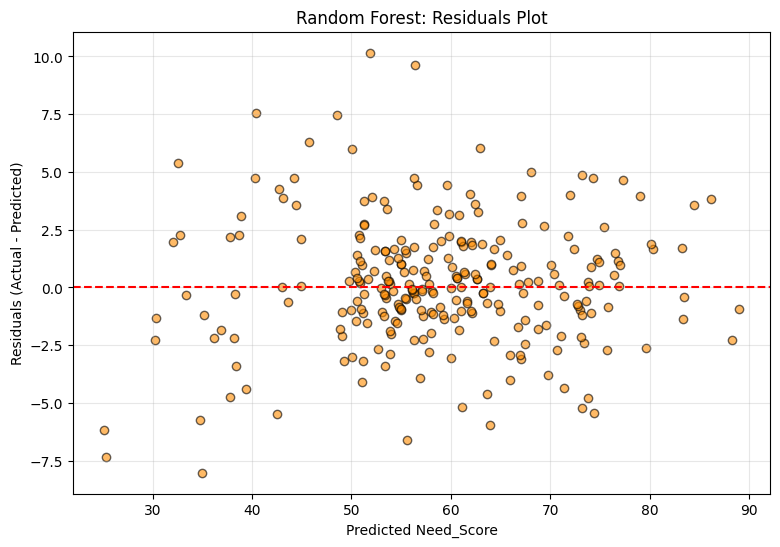

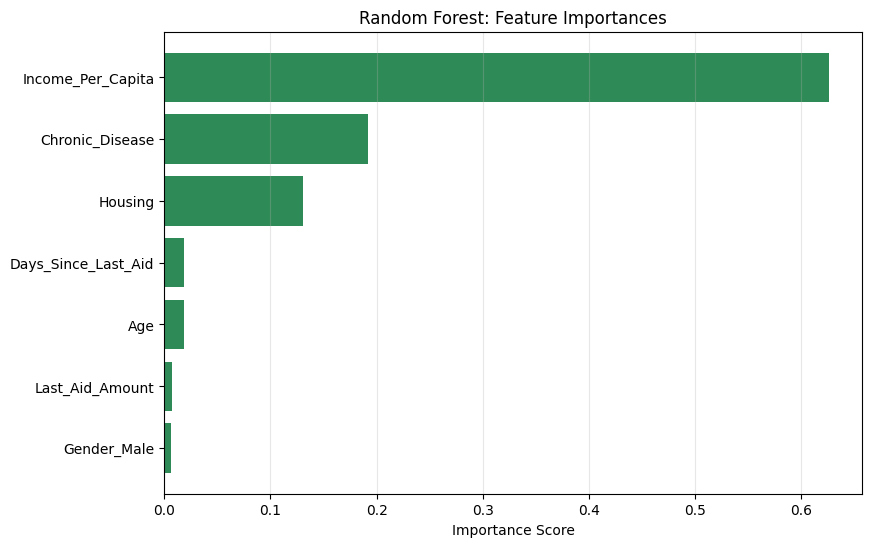


Final Dictionary Result:
{'Model': 'Random Forest', 'MSE': 7.362584651288996, 'MAE': 2.010510613907165, 'RMSE': np.float64(2.713408308988715), 'R2 Score': 0.9509058108577776, 'Mean CV R2': np.float64(0.9362412941131067)}


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv('يارب_تكون_اخر_مرة.csv')

df.head()

# ============================================================
# Check for missing values
# ============================================================
df.isnull().sum()

# ============================================================
# Encode categorical columns & Drop unnecessary columns
# ============================================================
# تحويل العمود النصي (Gender) إلى One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# استبعاد الأعمدة غير المطلوبة
cols_to_drop = ['ID', 'Name', 'Location', 'Category', 'Monthly_Income', 'Dependents']
df_model = df_encoded.drop(columns=cols_to_drop, errors='ignore')

df_model.head()

# ============================================================
# Prepare data
# ============================================================
x = df_model.drop(columns=['Need_Score'])
y = df_model['Need_Score']

# تقسيم البيانات (33% اختبار لتطابق تقسيم الكود الأول)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

x_train.shape, x_test.shape

# ============================================================
# Fine-Tuning with GridSearchCV & Train Random Forest
# ============================================================
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, n_jobs=-1)

print("جاري تدريب النموذج وتحديد أفضل Hyperparameters...")
grid_search.fit(x_train, y_train)

# اختيار أفضل نموذج
rf_model = grid_search.best_estimator_
print(f"أفضل إعدادات (Best Params): {grid_search.best_params_}")

# التنبؤ على بيانات الاختبار
y_pred = rf_model.predict(x_test)

# ============================================================
# Accuracy with 3 error types + R2
# ============================================================
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Test Evaluation ---")
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ============================================================
# Check overfitting (train vs test)
# ============================================================
train_pred = rf_model.predict(x_train)
print("\n--- Overfitting Check ---")
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred))

# ============================================================
# Cross Validation
# ============================================================
cv_scores = cross_val_score(rf_model, x, y, cv=5, scoring='r2')

print("\n--- Cross Validation ---")
print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

# ============================================================
# Plot 1: Cross Validation scores across folds
# ============================================================
plt.figure(figsize=(9, 6))
plt.plot(range(1, 6), cv_scores, marker="o", color='teal')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label='Mean R2')
plt.xlabel("Fold Number")
plt.ylabel("R2 Score")
plt.title("Random Forest: Cross Validation R2 Scores per Fold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 2: Actual vs Predicted
# ============================================================
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Need_Score")
plt.ylabel("Predicted Need_Score")
plt.title("Random Forest: Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 3: Residuals
# ============================================================
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='darkorange', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Need_Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Random Forest: Residuals Plot")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 4: Feature Importance (Badal Coefficients)
# ============================================================
importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color='seagreen')
plt.xlabel("Importance Score")
plt.title("Random Forest: Feature Importances")
plt.grid(alpha=0.3, axis='x')
plt.show()

# ============================================================
# Save this model's accuracy for later comparison
# ============================================================
random_forest_results = {
    "Model": "Random Forest",
    "MSE": mse,
    "MAE": mae,
    "RMSE": rmse,
    "R2 Score": r2,
    "Mean CV R2": cv_scores.mean()
}

print("\nFinal Dictionary Result:")
print(random_forest_results)

جاري تدريب نموذج SVR وتحديد أفضل Hyperparameters...
أفضل إعدادات (Best Params): {'svr__C': 100, 'svr__epsilon': 0.2, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}

--- Test Evaluation ---
MSE: 1.864231835201163
MAE: 1.154456265253082
RMSE: 1.3653687542935655
R2 Score: 0.9875691819303843

--- Overfitting Check ---
Train R2: 0.9877155678775325
Test R2: 0.9875691819303843

--- Cross Validation ---
CV R2 scores: [0.94300349 0.95786123 0.98890346 0.99163212 0.99151574]
Mean CV R2: 0.9745832079966293
Std CV R2: 0.020294573672353797


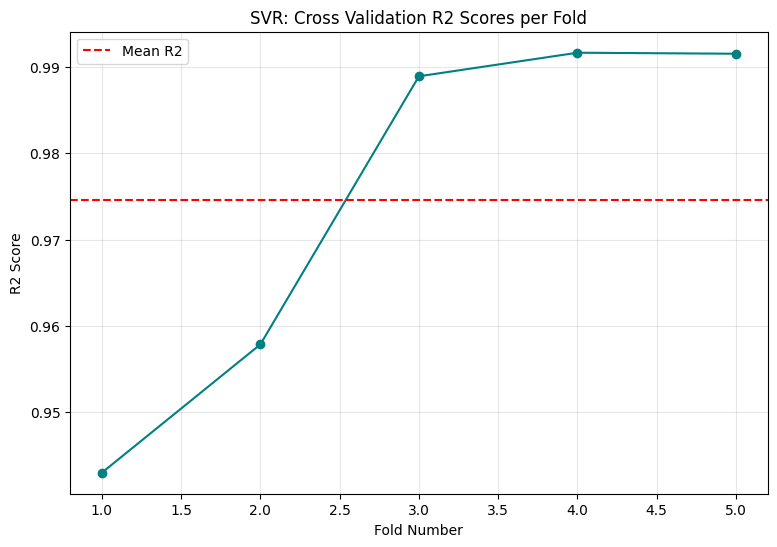

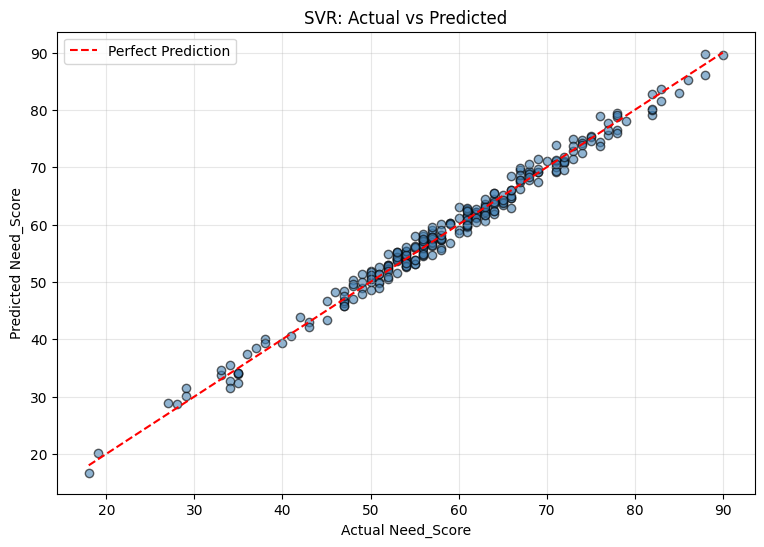

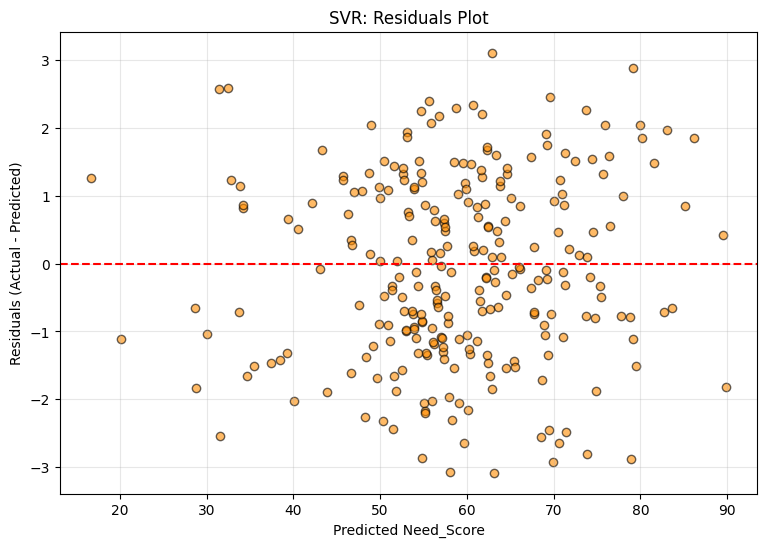

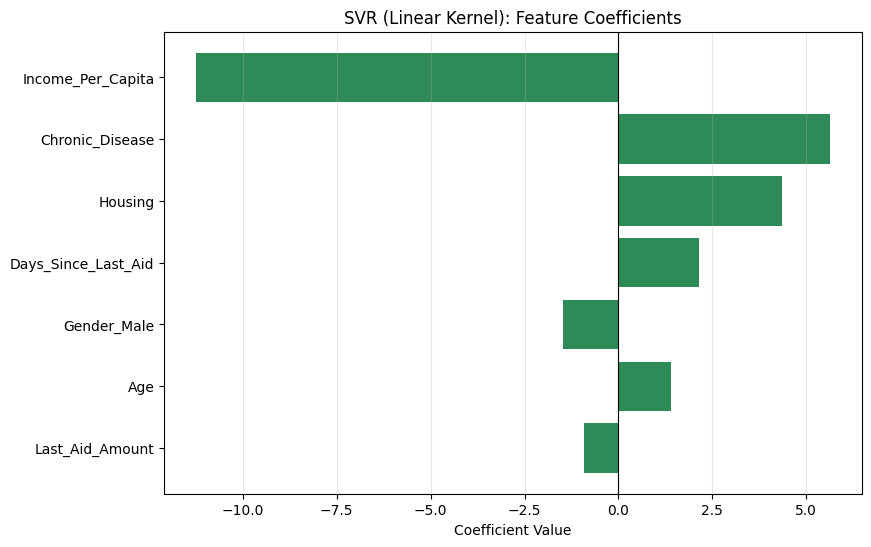


Final Dictionary Result:
{'Model': 'SVR', 'MSE': 1.864231835201163, 'MAE': 1.154456265253082, 'RMSE': np.float64(1.3653687542935655), 'R2 Score': 0.9875691819303843, 'Mean CV R2': np.float64(0.9745832079966293)}


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv('يارب_تكون_اخر_مرة.csv')

df.head()

# ============================================================
# Check for missing values
# ============================================================
df.isnull().sum()

# ============================================================
# Encode categorical columns & Drop unnecessary columns
# ============================================================
# تحويل العمود النصي (Gender) إلى One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# استبعاد الأعمدة غير المطلوبة
cols_to_drop = ['ID', 'Name', 'Location', 'Category', 'Monthly_Income', 'Dependents']
df_model = df_encoded.drop(columns=cols_to_drop, errors='ignore')

df_model.head()

# ============================================================
# Prepare data
# ============================================================
x = df_model.drop(columns=['Need_Score'])
y = df_model['Need_Score']

# تقسيم البيانات (33% اختبار لتطابق النماذج السابقة)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

x_train.shape, x_test.shape

# ============================================================
# Fine-Tuning with GridSearchCV & Train SVR (With Scaling)
# ============================================================
# استخدام Pipeline لضمان تطبيق Feature Scaling دون تسريب للبيانات
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

param_grid = {
    'svr__kernel': ['rbf', 'linear'],
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.2],
    'svr__gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, n_jobs=-1)

print("جاري تدريب نموذج SVR وتحديد أفضل Hyperparameters...")
grid_search.fit(x_train, y_train)

# اختيار أفضل نموذج
svr_model = grid_search.best_estimator_
print(f"أفضل إعدادات (Best Params): {grid_search.best_params_}")

# التنبؤ على بيانات الاختبار
y_pred = svr_model.predict(x_test)

# ============================================================
# Accuracy with 3 error types + R2
# ============================================================
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Test Evaluation ---")
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ============================================================
# Check overfitting (train vs test)
# ============================================================
train_pred = svr_model.predict(x_train)
print("\n--- Overfitting Check ---")
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred))

# ============================================================
# Cross Validation
# ============================================================
cv_scores = cross_val_score(svr_model, x, y, cv=5, scoring='r2')

print("\n--- Cross Validation ---")
print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

# ============================================================
# Plot 1: Cross Validation scores across folds
# ============================================================
plt.figure(figsize=(9, 6))
plt.plot(range(1, 6), cv_scores, marker="o", color='teal')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label='Mean R2')
plt.xlabel("Fold Number")
plt.ylabel("R2 Score")
plt.title("SVR: Cross Validation R2 Scores per Fold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 2: Actual vs Predicted
# ============================================================
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Need_Score")
plt.ylabel("Predicted Need_Score")
plt.title("SVR: Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 3: Residuals
# ============================================================
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='darkorange', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Need_Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("SVR: Residuals Plot")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 4: Feature Importance or Coefficients
# ============================================================
# استخراج أهمية المتغيرات إذا كان Kernel خرساني (Linear)، وإلا نستخدم الـ Permutation Importance للـ RBF Kernel
best_svr = svr_model.named_steps['svr']

if best_svr.kernel == 'linear':
    coefs = best_svr.coef_[0]
    importance_df = pd.DataFrame({
        "Feature": x_train.columns,
        "Importance": coefs
    }).sort_values("Importance", key=abs, ascending=True)
    
    plt.figure(figsize=(9, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"], color='seagreen')
    plt.xlabel("Coefficient Value")
    plt.title("SVR (Linear Kernel): Feature Coefficients")
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.grid(alpha=0.3, axis='x')
    plt.show()
else:
    from sklearn.inspection import permutation_importance
    perm_importance = permutation_importance(svr_model, x_test, y_test, random_state=42)
    importance_df = pd.DataFrame({
        "Feature": x_train.columns,
        "Importance": perm_importance.importances_mean
    }).sort_values("Importance", ascending=True)

    plt.figure(figsize=(9, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"], color='seagreen')
    plt.xlabel("Permutation Importance")
    plt.title("SVR (RBF Kernel): Feature Importance")
    plt.grid(alpha=0.3, axis='x')
    plt.show()

# ============================================================
# Save this model's accuracy for later comparison
# ============================================================
svr_results = {
    "Model": "SVR",
    "MSE": mse,
    "MAE": mae,
    "RMSE": rmse,
    "R2 Score": r2,
    "Mean CV R2": cv_scores.mean()
}

print("\nFinal Dictionary Result:")
print(svr_results)

جاري تدريب نموذج Decision Tree وتحديد أفضل Hyperparameters...
أفضل إعدادات (Best Params): {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

--- Test Evaluation ---
MSE: 11.135618747339294
MAE: 2.448584504044274
RMSE: 3.3370074538932775
R2 Score: 0.9257469762467394

--- Overfitting Check ---
Train R2: 0.9994431718190073
Test R2: 0.9257469762467394

--- Cross Validation ---
CV R2 scores: [0.73893626 0.8647603  0.91754215 0.92933129 0.89589006]
Mean CV R2: 0.8692920106446012
Std CV R2: 0.06877994800320483


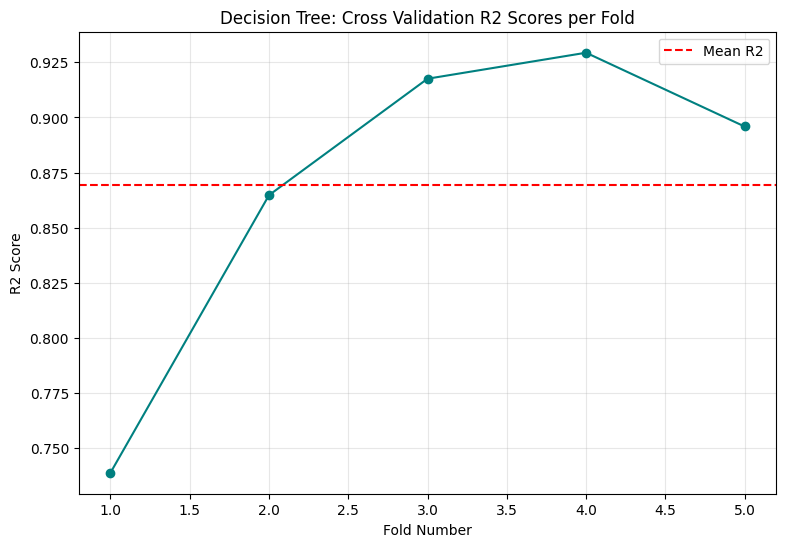

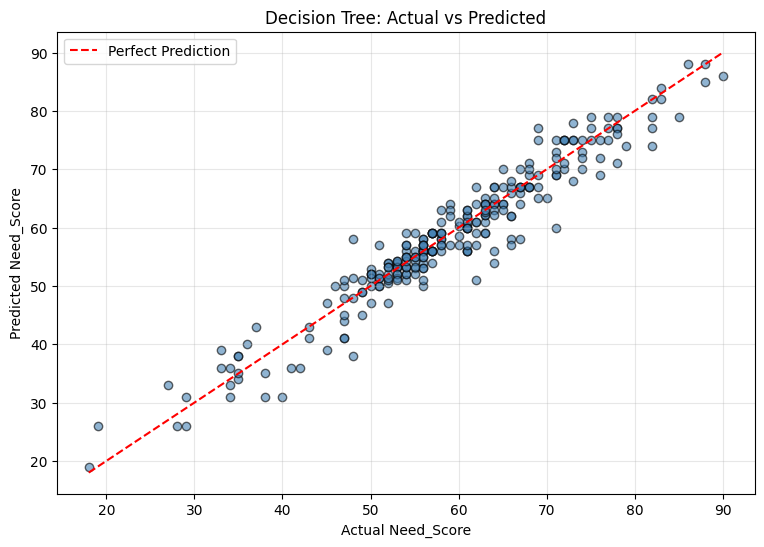

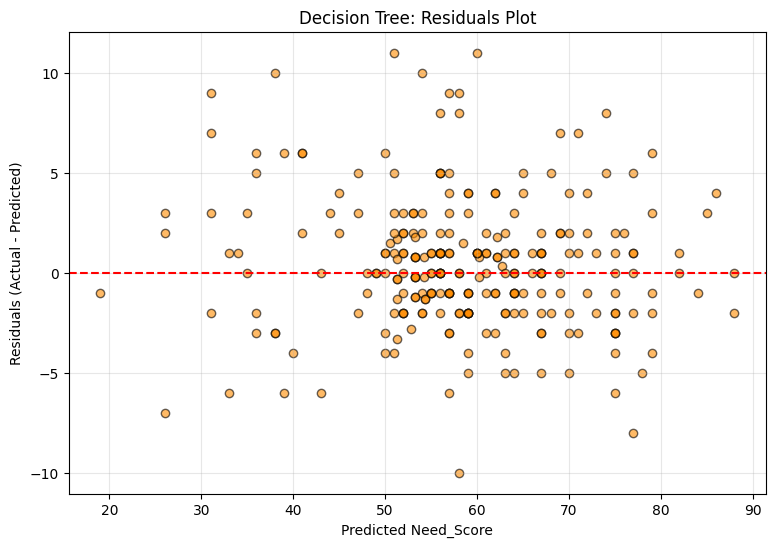

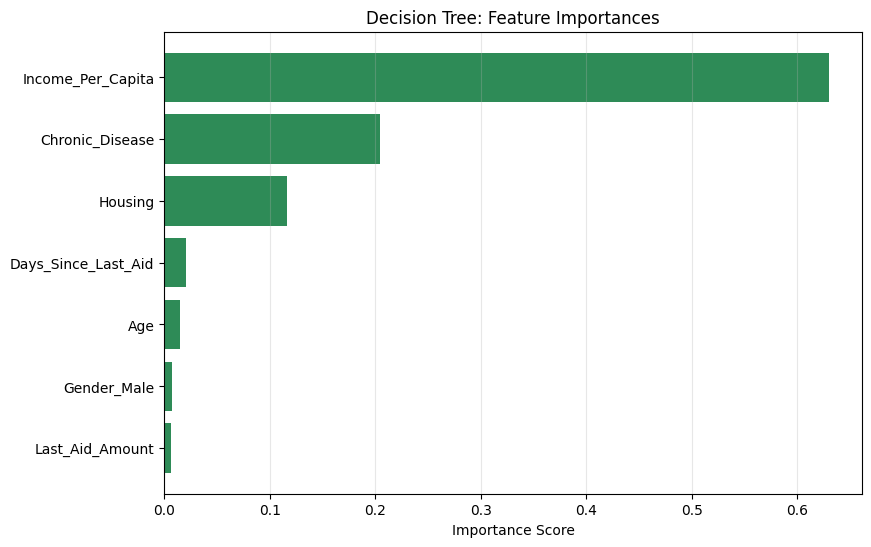


Final Dictionary Result:
{'Model': 'Decision Tree', 'MSE': 11.135618747339294, 'MAE': 2.448584504044274, 'RMSE': np.float64(3.3370074538932775), 'R2 Score': 0.9257469762467394, 'Mean CV R2': np.float64(0.8692920106446012)}


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv('يارب_تكون_اخر_مرة.csv')

df.head()

# ============================================================
# Check for missing values
# ============================================================
df.isnull().sum()

# ============================================================
# Encode categorical columns & Drop unnecessary columns
# ============================================================
# تحويل العمود النصي (Gender) إلى One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# استبعاد الأعمدة غير المطلوبة
cols_to_drop = ['ID', 'Name', 'Location', 'Category', 'Monthly_Income', 'Dependents']
df_model = df_encoded.drop(columns=cols_to_drop, errors='ignore')

df_model.head()

# ============================================================
# Prepare data
# ============================================================
x = df_model.drop(columns=['Need_Score'])
y = df_model['Need_Score']

# تقسيم البيانات (33% اختبار لتطابق النماذج السابقة)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

x_train.shape, x_test.shape

# ============================================================
# Fine-Tuning with GridSearchCV & Train Decision Tree
# ============================================================
param_grid = {
    'max_depth': [3, 5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

dt_base = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(estimator=dt_base, param_grid=param_grid, cv=5, n_jobs=-1)

print("جاري تدريب نموذج Decision Tree وتحديد أفضل Hyperparameters...")
grid_search.fit(x_train, y_train)

# اختيار أفضل نموذج
dt_model = grid_search.best_estimator_
print(f"أفضل إعدادات (Best Params): {grid_search.best_params_}")

# التنبؤ على بيانات الاختبار
y_pred = dt_model.predict(x_test)

# ============================================================
# Accuracy with 3 error types + R2
# ============================================================
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Test Evaluation ---")
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ============================================================
# Check overfitting (train vs test)
# ============================================================
train_pred = dt_model.predict(x_train)
print("\n--- Overfitting Check ---")
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred))

# ============================================================
# Cross Validation
# ============================================================
cv_scores = cross_val_score(dt_model, x, y, cv=5, scoring='r2')

print("\n--- Cross Validation ---")
print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

# ============================================================
# Plot 1: Cross Validation scores across folds
# ============================================================
plt.figure(figsize=(9, 6))
plt.plot(range(1, 6), cv_scores, marker="o", color='teal')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label='Mean R2')
plt.xlabel("Fold Number")
plt.ylabel("R2 Score")
plt.title("Decision Tree: Cross Validation R2 Scores per Fold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 2: Actual vs Predicted
# ============================================================
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Need_Score")
plt.ylabel("Predicted Need_Score")
plt.title("Decision Tree: Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 3: Residuals
# ============================================================
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='darkorange', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Need_Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Decision Tree: Residuals Plot")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 4: Feature Importance
# ============================================================
importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color='seagreen')
plt.xlabel("Importance Score")
plt.title("Decision Tree: Feature Importances")
plt.grid(alpha=0.3, axis='x')
plt.show()

# ============================================================
# Save this model's accuracy for later comparison
# ============================================================
decision_tree_results = {
    "Model": "Decision Tree",
    "MSE": mse,
    "MAE": mae,
    "RMSE": rmse,
    "R2 Score": r2,
    "Mean CV R2": cv_scores.mean()
}

print("\nFinal Dictionary Result:")
print(decision_tree_results)

جاري تدريب نموذج AdaBoost وتحديد أفضل Hyperparameters...
أفضل إعدادات (Best Params): {'learning_rate': 1.0, 'loss': 'square', 'n_estimators': 200}

--- Test Evaluation ---
MSE: 11.56941146654046
MAE: 2.5915109861543453
RMSE: 3.4013837576110784
R2 Score: 0.9228544184272172

--- Overfitting Check ---
Train R2: 0.9573671809955608
Test R2: 0.9228544184272172

--- Cross Validation ---
CV R2 scores: [0.70264112 0.86094842 0.95395272 0.93763987 0.94564363]
Mean CV R2: 0.8801651520028273
Std CV R2: 0.0947833775467541


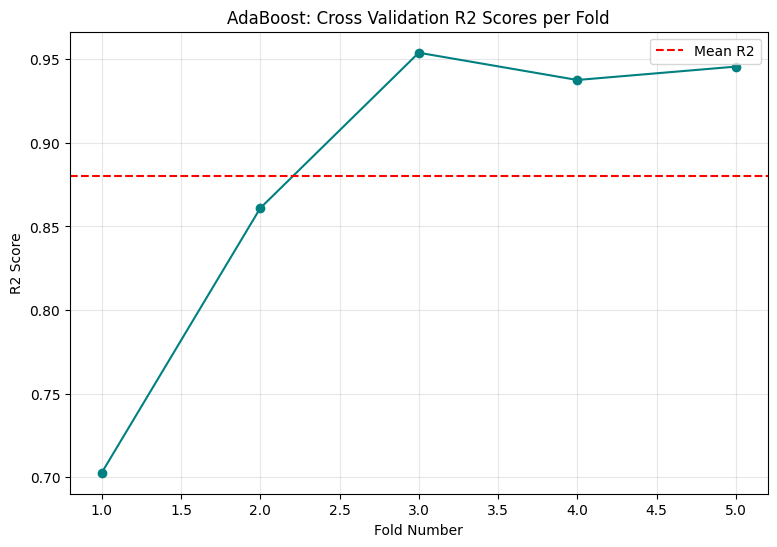

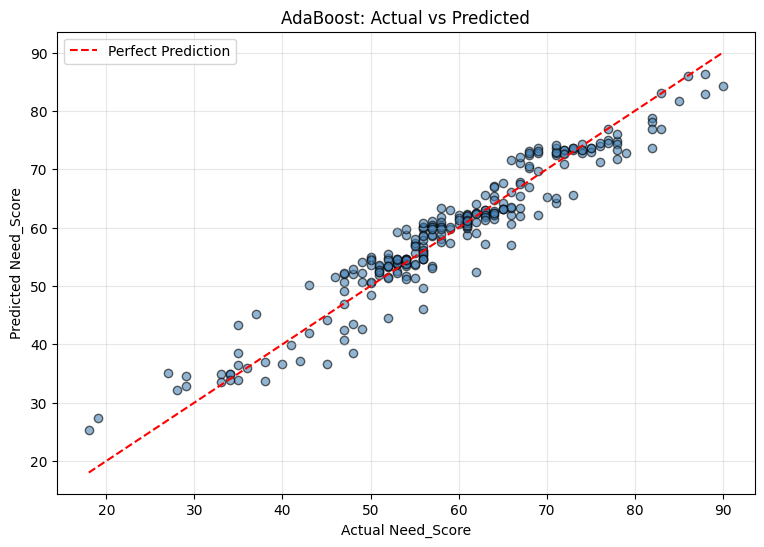

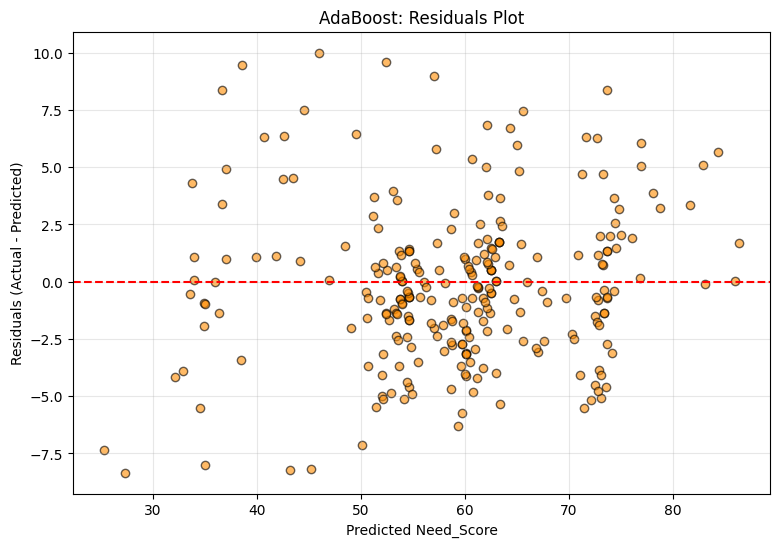

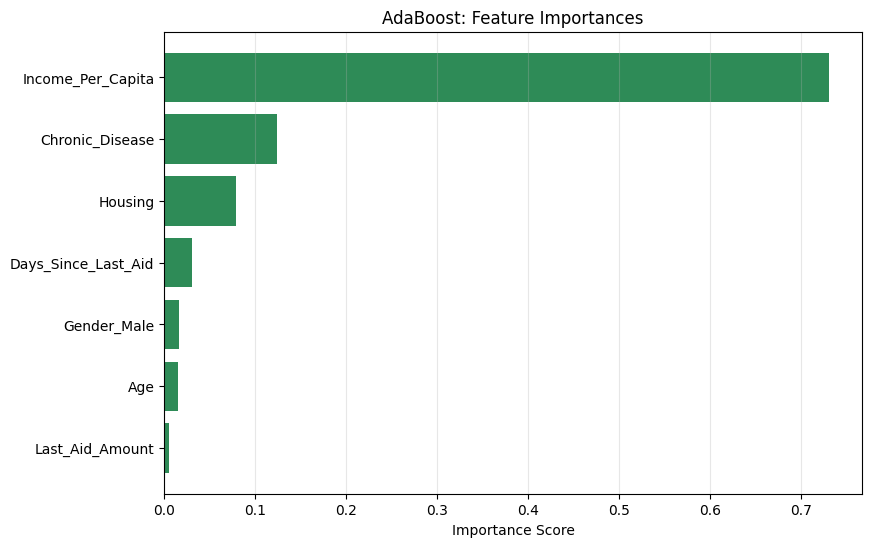


Final Dictionary Result:
{'Model': 'AdaBoost', 'MSE': 11.56941146654046, 'MAE': 2.5915109861543453, 'RMSE': np.float64(3.4013837576110784), 'R2 Score': 0.9228544184272172, 'Mean CV R2': np.float64(0.8801651520028273)}


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# Load dataset
# ============================================================
df = pd.read_csv('يارب_تكون_اخر_مرة.csv')

df.head()

# ============================================================
# Check for missing values
# ============================================================
df.isnull().sum()

# ============================================================
# Encode categorical columns & Drop unnecessary columns
# ============================================================
# تحويل العمود النصي (Gender) إلى One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Gender'], drop_first=True)

# استبعاد الأعمدة غير المطلوبة
cols_to_drop = ['ID', 'Name', 'Location', 'Category', 'Monthly_Income', 'Dependents']
df_model = df_encoded.drop(columns=cols_to_drop, errors='ignore')

df_model.head()

# ============================================================
# Prepare data
# ============================================================
x = df_model.drop(columns=['Need_Score'])
y = df_model['Need_Score']

# تقسيم البيانات (33% اختبار لتطابق النماذج السابقة)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

x_train.shape, x_test.shape

# ============================================================
# Fine-Tuning with GridSearchCV & Train AdaBoost
# ============================================================
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 1.0],
    'loss': ['linear', 'square', 'exponential']
}

ada_base = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=4, random_state=42),
    random_state=42
)
grid_search = GridSearchCV(estimator=ada_base, param_grid=param_grid, cv=5, n_jobs=-1)

print("جاري تدريب نموذج AdaBoost وتحديد أفضل Hyperparameters...")
grid_search.fit(x_train, y_train)

# اختيار أفضل نموذج
ada_model = grid_search.best_estimator_
print(f"أفضل إعدادات (Best Params): {grid_search.best_params_}")

# التنبؤ على بيانات الاختبار
y_pred = ada_model.predict(x_test)

# ============================================================
# Accuracy with 3 error types + R2
# ============================================================
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Test Evaluation ---")
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

# ============================================================
# Check overfitting (train vs test)
# ============================================================
train_pred = ada_model.predict(x_train)
print("\n--- Overfitting Check ---")
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, y_pred))

# ============================================================
# Cross Validation
# ============================================================
cv_scores = cross_val_score(ada_model, x, y, cv=5, scoring='r2')

print("\n--- Cross Validation ---")
print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

# ============================================================
# Plot 1: Cross Validation scores across folds
# ============================================================
plt.figure(figsize=(9, 6))
plt.plot(range(1, 6), cv_scores, marker="o", color='teal')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label='Mean R2')
plt.xlabel("Fold Number")
plt.ylabel("R2 Score")
plt.title("AdaBoost: Cross Validation R2 Scores per Fold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 2: Actual vs Predicted
# ============================================================
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Need_Score")
plt.ylabel("Predicted Need_Score")
plt.title("AdaBoost: Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 3: Residuals
# ============================================================
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='darkorange', edgecolors='k')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Need_Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("AdaBoost: Residuals Plot")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Plot 4: Feature Importance
# ============================================================
importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": ada_model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color='seagreen')
plt.xlabel("Importance Score")
plt.title("AdaBoost: Feature Importances")
plt.grid(alpha=0.3, axis='x')
plt.show()

# ============================================================
# Save this model's accuracy for later comparison
# ============================================================
adaboost_results = {
    "Model": "AdaBoost",
    "MSE": mse,
    "MAE": mae,
    "RMSE": rmse,
    "R2 Score": r2,
    "Mean CV R2": cv_scores.mean()
}

print("\nFinal Dictionary Result:")
print(adaboost_results)

=== Models Accuracy Comparison ===
            Model       MSE      MAE     RMSE  R2 Score  Mean CV R2
Linear Regression  1.826945 1.137687 1.351645  0.987818    0.974773
              SVR  1.864232 1.154456 1.365369  0.987569    0.974583
          XGBoost  4.366273 1.588375 2.089563  0.970885    0.961910
    Random Forest  7.362585 2.010511 2.713408  0.950906    0.936241
    Decision Tree 11.135619 2.448585 3.337007  0.925747    0.869292
         AdaBoost 11.569411 2.591511 3.401384  0.922854    0.880165


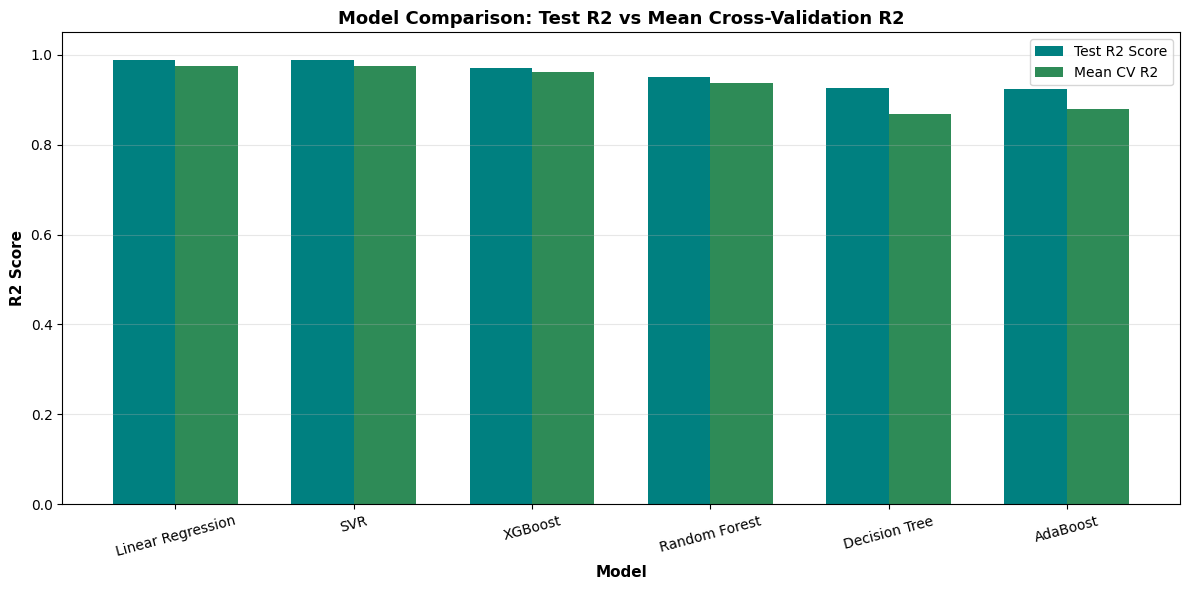

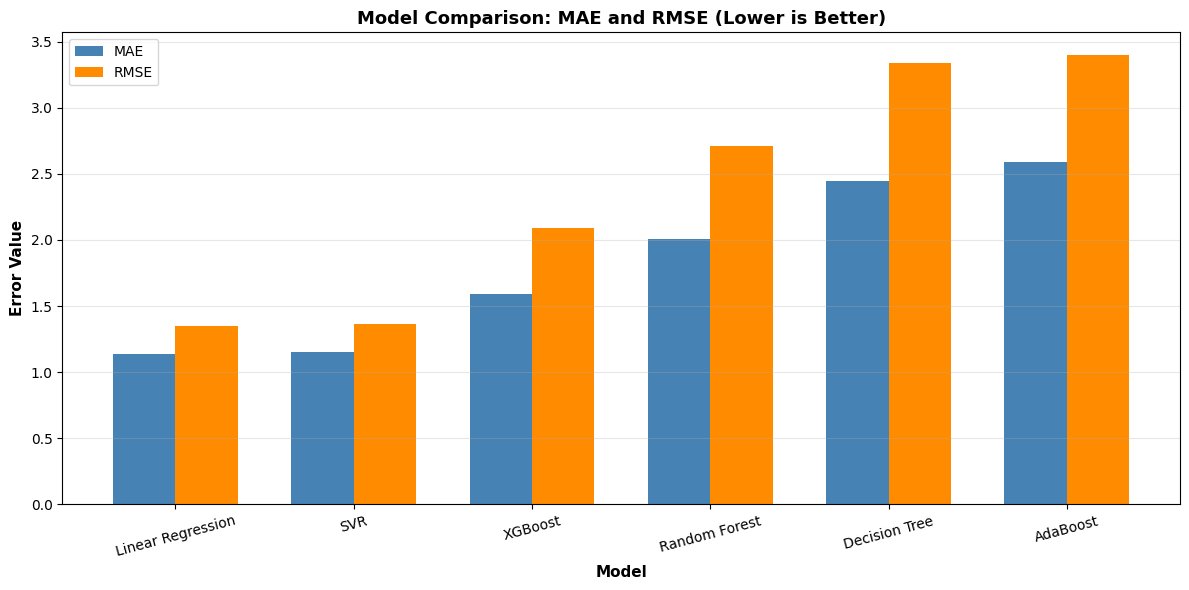


🏆 أفضل نموذج بناءً على دقة R2 Score هو: Linear Regression بدقة تساوي 0.9878


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Combine ALL model results into a single DataFrame
# ============================================================
results_list = [
    linear_regression_results,
    decision_tree_results,
    random_forest_results,
    xgboost_results,
    svr_results,
    adaboost_results
]

# (ملاحظة: لو عندك كمان knn_results أضيفيه للقائمة أعلاه ببساطة)

# تحويل القائمة لـ DataFrame مرتبة تنازلياً حسب دقة الـ R2 Score
comparison_df = pd.DataFrame(results_list).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)

print("=== Models Accuracy Comparison ===")
print(comparison_df.to_string(index=False))

# ============================================================
# Dynamic positioning setup for plotting all models
# ============================================================
x_labels = comparison_df['Model']
x_indices = np.arange(len(x_labels))
width = 0.35

# ============================================================
# Plot 1: R2 Score & Mean CV R2 Comparison (Higher is Better)
# ============================================================
plt.figure(figsize=(12, 6))

plt.bar(x_indices - width/2, comparison_df['R2 Score'], width=width, label='Test R2 Score', color='teal')
plt.bar(x_indices + width/2, comparison_df['Mean CV R2'], width=width, label='Mean CV R2', color='seagreen')

plt.xlabel("Model", fontsize=11, fontweight='bold')
plt.ylabel("R2 Score", fontsize=11, fontweight='bold')
plt.title("Model Comparison: Test R2 vs Mean Cross-Validation R2", fontsize=13, fontweight='bold')
plt.xticks(x_indices, x_labels, rotation=15)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: MAE & RMSE Comparison (Lower is Better)
# ============================================================
plt.figure(figsize=(12, 6))

plt.bar(x_indices - width/2, comparison_df['MAE'], width=width, label='MAE', color='steelblue')
plt.bar(x_indices + width/2, comparison_df['RMSE'], width=width, label='RMSE', color='darkorange')

plt.xlabel("Model", fontsize=11, fontweight='bold')
plt.ylabel("Error Value", fontsize=11, fontweight='bold')
plt.title("Model Comparison: MAE and RMSE (Lower is Better)", fontsize=13, fontweight='bold')
plt.xticks(x_indices, x_labels, rotation=15)
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# Highlight Best Model
# ============================================================
best_model_name = comparison_df.iloc[0]['Model']
best_r2 = comparison_df.iloc[0]['R2 Score']
print(f"\n🏆 أفضل نموذج بناءً على دقة R2 Score هو: {best_model_name} بدقة تساوي {best_r2:.4f}")